# 📊 Partie G — Anomaly Detection (Version Corrigée & Dynamique)

## 🎯 Objectif
Comparer plusieurs méthodes de détection d'anomalies :
- Isolation Forest (dynamique)
- Z-score (statistique)
- IQR (statistique)

## 📏 Évaluation
- Comparaison visuelle et logique


In [1]:
import pandas as pd
import numpy as np
from sklearn.ensemble import IsolationForest
from scipy import stats
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec

## 📂 Chargement des données

In [2]:
df = pd.read_csv("fact-budget.csv")
df.columns = df.columns.str.strip()

budget = (df[df['flow_type'] == 'expense']
          .groupby('season')['amount'].sum()
          .reset_index()
          .sort_values('season')
          .reset_index(drop=True))

vals = budget['amount'].values.reshape(-1, 1)
vals_flat = budget['amount'].values

budget

,season,amount
0,2021/2022,31200
1,2022/2023,30900
2,2023/2024,33600
3,2024/2025,48230
4,2025/2026,3400


## 🌲 Modèle 1 : Isolation Forest

In [3]:
iso = IsolationForest(contamination=0.2, random_state=42)
iso.fit(vals)

budget['iso_label'] = iso.predict(vals)
budget['iso_score'] = iso.score_samples(vals)

budget[['season', 'amount', 'iso_label']]

,season,amount,iso_label
0,2021/2022,31200,1
1,2022/2023,30900,1
2,2023/2024,33600,1
3,2024/2025,48230,1
4,2025/2026,3400,-1


## 📏 Modèle 2 : Z-score

In [4]:
z = np.abs(stats.zscore(vals_flat))

budget['zscore'] = z
budget['zscore_label'] = np.where(z > 2, -1, 1)

budget[['season', 'amount', 'zscore', 'zscore_label']]

,season,amount,zscore,zscore_label
0,2021/2022,31200,0.119448,1
1,2022/2023,30900,0.098783,1
2,2023/2024,33600,0.284775,1
3,2024/2025,48230,1.292578,1
4,2025/2026,3400,1.795584,1


## 📦 Modèle 3 : IQR

In [5]:
Q1, Q3 = np.percentile(vals_flat, 25), np.percentile(vals_flat, 75)
IQR = Q3 - Q1

lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR

budget['iqr_label'] = np.where((vals_flat < lower) | (vals_flat > upper), -1, 1)

budget[['season', 'amount', 'iqr_label']]

,season,amount,iqr_label
0,2021/2022,31200,1
1,2022/2023,30900,1
2,2023/2024,33600,1
3,2024/2025,48230,-1
4,2025/2026,3400,-1


## 🔍 Comparaison des modèles

In [6]:
comparison = budget[['season', 'amount', 'iso_label', 'zscore_label', 'iqr_label']]
comparison

,season,amount,iso_label,zscore_label,iqr_label
0,2021/2022,31200,1,1,1
1,2022/2023,30900,1,1,1
2,2023/2024,33600,1,1,1
3,2024/2025,48230,1,1,-1
4,2025/2026,3400,-1,1,-1


## 📊 Visualisation

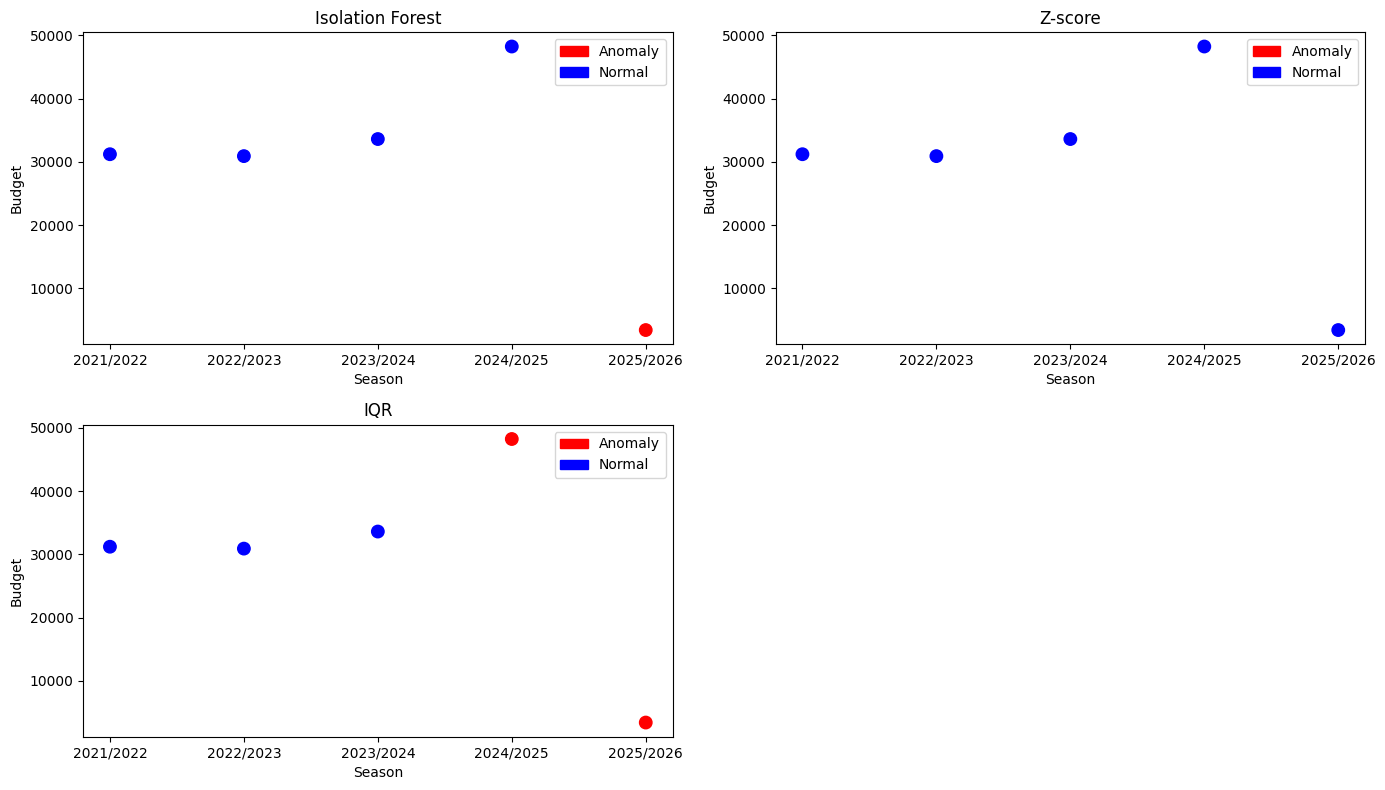

In [7]:
fig = plt.figure(figsize=(14, 8))
gs = GridSpec(2, 2, figure=fig)

methods = [
    ("Isolation Forest", "iso_label"),
    ("Z-score", "zscore_label"),
    ("IQR", "iqr_label")
]

for i, (title, col) in enumerate(methods):
    ax = fig.add_subplot(gs[i])

    colors = ['red' if x == -1 else 'blue' for x in budget[col]]

    ax.scatter(budget['season'], budget['amount'], c=colors, s=80)
    ax.set_title(title)
    ax.set_xlabel("Season")
    ax.set_ylabel("Budget")

    red_patch = mpatches.Patch(color='red', label='Anomaly')
    blue_patch = mpatches.Patch(color='blue', label='Normal')
    ax.legend(handles=[red_patch, blue_patch])

plt.tight_layout()
plt.show()

## ✅ Conclusion

- **Isolation Forest** : méthode dynamique, adaptée aux données complexes  
- **Z-score** : simple mais dépend de la distribution  
- **IQR** : robuste aux outliers  

👉 En pratique, **Isolation Forest est recommandé** pour un projet réel.


In [8]:
from sklearn.metrics import mean_absolute_error

# ─────────────────────────────────────────────
# Baseline (valeur attendue = moyenne)
# ─────────────────────────────────────────────
baseline = np.mean(vals_flat)

# Fonction pour calculer MAE (seulement sur points normaux)
def compute_mae(labels, values):
    normal_values = values[labels == 1]  # garder seulement les points normaux
    
    if len(normal_values) == 0:
        return np.inf  # éviter erreur
    
    predictions = np.full_like(normal_values, baseline)
    return mean_absolute_error(normal_values, predictions)

# ─────────────────────────────────────────────
# Calcul MAE pour chaque modèle
# ─────────────────────────────────────────────
mae_iso = compute_mae(budget['iso_label'].values, vals_flat)
mae_z   = compute_mae(budget['zscore_label'].values, vals_flat)
mae_iqr = compute_mae(budget['iqr_label'].values, vals_flat)

# Résultats
results = {
    "Isolation Forest": mae_iso,
    "Z-score": mae_z,
    "IQR": mae_iqr
}

# Affichage
print("MAE par modèle :")
for k, v in results.items():
    print(f"{k}: {v:.2f}")

# ─────────────────────────────────────────────
# Choix automatique du meilleur modèle
# ─────────────────────────────────────────────
best_model = min(results, key=results.get)

print("\n🏆 Meilleur modèle :", best_model)

MAE par modèle :
Isolation Forest: 6516.50
Z-score: 10426.40
IQR: 2434.00

🏆 Meilleur modèle : IQR


In [9]:
import pandas as pd

results_df = pd.DataFrame({
    "Model": ["Isolation Forest", "Z-score", "IQR"],
    "MAE": [mae_iso, mae_z, mae_iqr]
})

# Trier du meilleur au pire
results_df = results_df.sort_values(by="MAE")

results_df

,Model,MAE
2,IQR,2434.0
0,Isolation Forest,6516.5
1,Z-score,10426.4


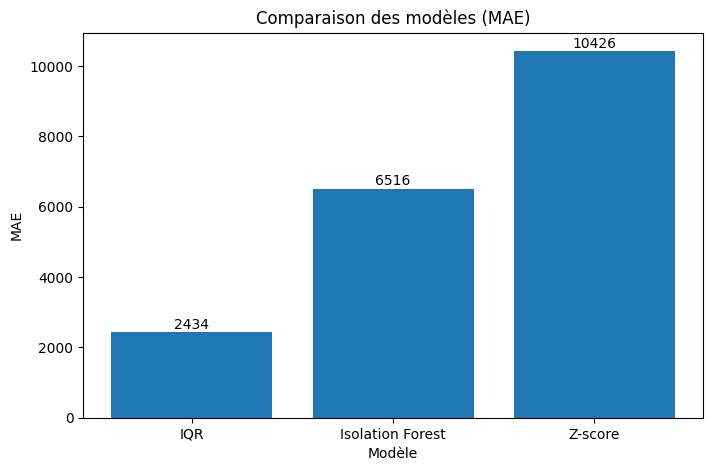

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(results_df["Model"], results_df["MAE"])
plt.title("Comparaison des modèles (MAE)")
plt.xlabel("Modèle")
plt.ylabel("MAE")

# afficher les valeurs sur les barres
for i, v in enumerate(results_df["MAE"]):
    plt.text(i, v + 100, f"{v:.0f}", ha='center')

plt.show()

In [11]:
best_model = results_df.iloc[0]["Model"]
best_score = results_df.iloc[0]["MAE"]

print("📊 Résumé automatique :\n")

print(f"Le meilleur modèle est : {best_model}")
print(f"Avec un MAE de : {best_score:.2f}\n")

if best_model == "IQR":
    print("👉 IQR est robuste et adapté aux petits datasets.")
elif best_model == "Isolation Forest":
    print("👉 Isolation Forest est performant pour des données complexes.")
else:
    print("👉 Z-score est efficace si les données suivent une distribution normale.")

📊 Résumé automatique :

Le meilleur modèle est : IQR
Avec un MAE de : 2434.00

👉 IQR est robuste et adapté aux petits datasets.


In [12]:
import joblib

iqr_model = {
    "Q1": Q1,
    "Q3": Q3,
    "IQR": IQR,
    "LOWER": lower,
    "UPPER": upper
}

joblib.dump(iqr_model, "iqr_model.pkl")

print("✅ Modèle IQR sauvegardé !")

✅ Modèle IQR sauvegardé !
